# EDA — Exploratory Data Analysis
---
**Objective:** To explore data and create comprehensive graphs

**Input:** `Silver_Layer/US_Accidents_Silver.csv`

**Output:** Graphs + `roadway_features_analysis.png`

## 1. Imports & Global Style

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
MAIN_GRAY  = '#696969'
LIGHT_GRAY = '#a9a9a9'
GRAY4      = ['#d3d3d3', '#a9a9a9', '#808080', '#696969']
print('Imports done')

Imports done


## 2. Load Data & Feature Engineering

In [2]:
df = pd.read_csv('Silver_Layer/US_Accidents_Silver.csv')
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce', format='mixed')
df['End_Time']   = pd.to_datetime(df['End_Time'],   errors='coerce', format='mixed')

df['Hour']              = df['Start_Time'].dt.hour
df['Day_of_Week']       = df['Start_Time'].dt.day_name()
df['Month']             = df['Start_Time'].dt.month
df['Year']              = df['Start_Time'].dt.year
df['Wind_Chill_Effect'] = df['Temperature(F)'] - df['Wind_Chill(F)']

df['Is_Extreme_Weather'] = (
    (df['Visibility(mi)'] <= 1.0) |
    (df['Precipitation(in)'] > 0.1) |
    (df['Weather_Condition'].str.contains('Snow|Heavy', na=False))
).astype(int)

df['Visibility_Category'] = pd.cut(
    df['Visibility(mi)'],
    bins=[0, 2, 7, float('inf')],
    labels=['Low (0-2 mi)', 'Moderate (2-7 mi)', 'High (>7 mi)'])

# نسخة للرسم مع capping للأعمدة الـ skewed
df_plot = df.copy()
for col in ['Wind_Speed(mph)', 'Precipitation(in)', 'Wind_Chill_Effect', 'Distance(mi)']:
    if col in df_plot.columns:
        df_plot[col] = df_plot[col].clip(upper=df_plot[col].quantile(0.99))

print(f'Loaded: {df.shape[0]:,} rows | {df.shape[1]} columns')

Loaded: 500,000 rows | 53 columns


## 3. Helper Function — Numeric Distribution Plot

In [3]:
def plot_env(data, col, bin_size, ax=None):
    series = data[col].dropna()
    min_   = np.floor(series.min() / bin_size) * bin_size
    max_   = np.ceil(series.max()  / bin_size) * bin_size
    bins   = np.arange(min_, max_ + bin_size, bin_size)
    labels = [f'{round(bins[i],2)}-{round(bins[i+1],2)}' for i in range(len(bins)-1)]
    binned = pd.cut(series, bins=bins, labels=labels, include_lowest=True)
    counts = binned.value_counts().sort_index()
    total  = len(series)
    pcts   = (counts / total) * 100
    colors = [LIGHT_GRAY if p == pcts.max() else MAIN_GRAY for p in pcts]
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(counts.index.astype(str), counts.values, color=colors)
    for bar, pct in zip(bars, pcts):
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + total * 0.003,
                    f'{pct:.1f}%', ha='center', fontsize=7, fontweight='bold')
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Accident Count', fontsize=11)
    ax.set_title(f'Distribution by {col}', fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    if standalone:
        plt.tight_layout(); plt.show(); plt.close()

print('Helper function ready')

Helper function ready


## 4. Severity Distribution

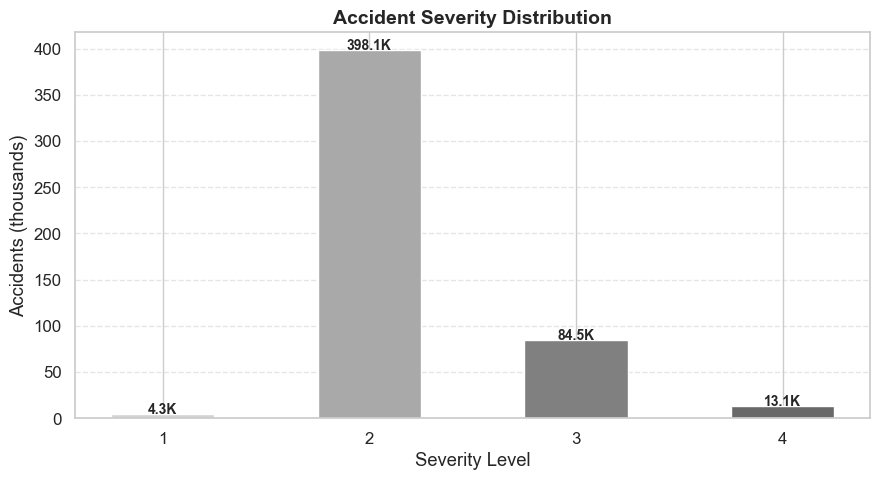

In [4]:
sev = df['Severity'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(sev.index.astype(str), sev.values / 1_000, width=0.5, color=GRAY4)
for bar, val in zip(bars, sev.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val/1000:.1f}K', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Accident Severity Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Severity Level'); ax.set_ylabel('Accidents (thousands)')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show(); plt.close()

## 5. Geography — Top Streets / Cities / States

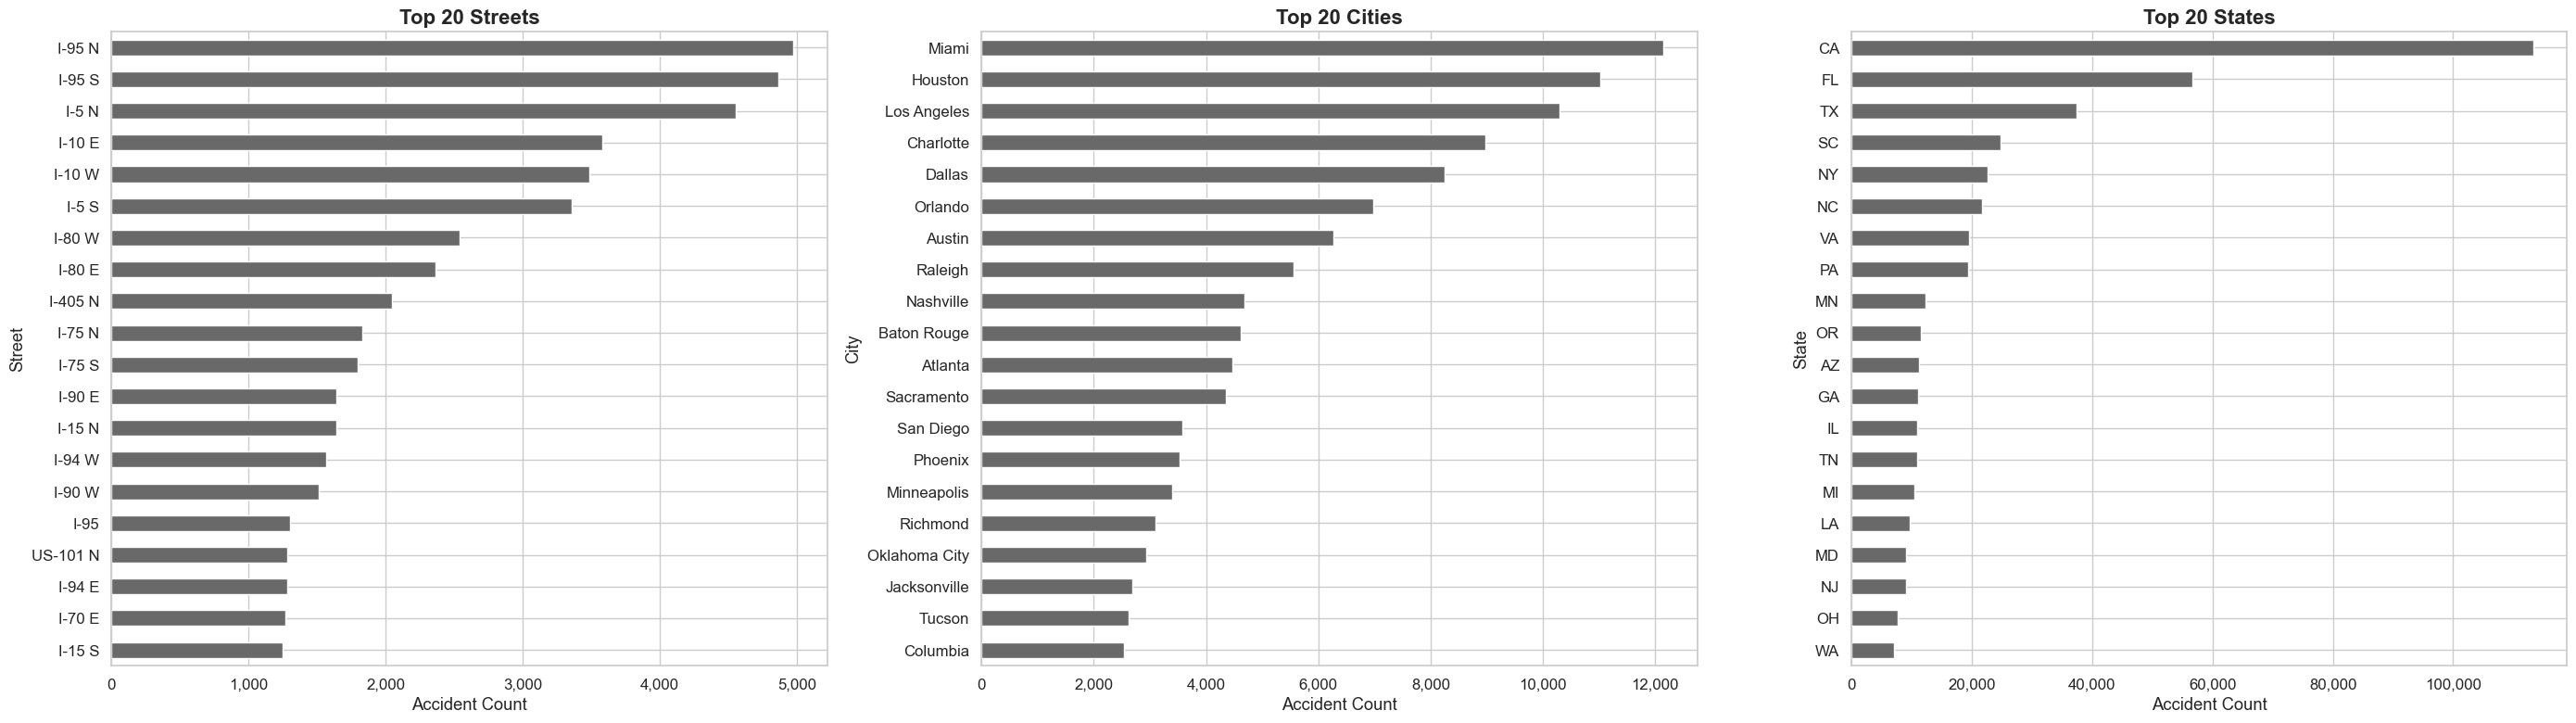

Streets >= 1000 accidents: 29  (0.03%)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(28, 8))
for ax, col, title in zip(axes,
    ['Street', 'City', 'State'],
    ['Top 20 Streets', 'Top 20 Cities', 'Top 20 States']):
    top = df[col].value_counts().head(20).sort_values(ascending=True)
    top.plot(kind='barh', color=MAIN_GRAY, ax=ax)
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel('Accident Count'); ax.set_ylabel(col)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout(); plt.show(); plt.close()

total_streets = df['Street'].nunique()
high_risk     = (df['Street'].value_counts() >= 1000).sum()
print(f'Streets >= 1000 accidents: {high_risk:,}  ({high_risk/total_streets*100:.2f}%)')

## 6. Temporal Analysis — Yearly

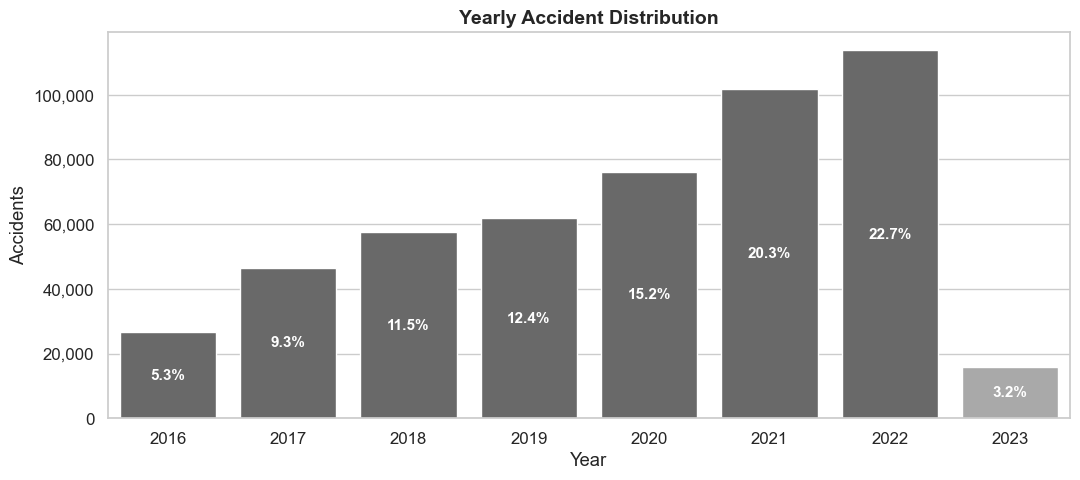

In [6]:
date_year = df['Year'].value_counts().reset_index()
date_year.columns = ['Year', 'Count']
date_year = date_year.sort_values('Year')
total = len(df)

fig, ax = plt.subplots(figsize=(11, 5))
colors_y = [LIGHT_GRAY if i == len(date_year)-1 else MAIN_GRAY for i in range(len(date_year))]
sns.barplot(data=date_year, x='Year', y='Count',
            palette=colors_y, hue='Year', legend=False, ax=ax)
for patch in ax.patches:
    h = patch.get_height()
    ax.text(patch.get_x() + patch.get_width()/2, h/2,
            f'{h/total*100:.1f}%', ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
ax.set_title('Yearly Accident Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Accidents')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout(); plt.show(); plt.close()

## 7. Temporal Analysis — Monthly

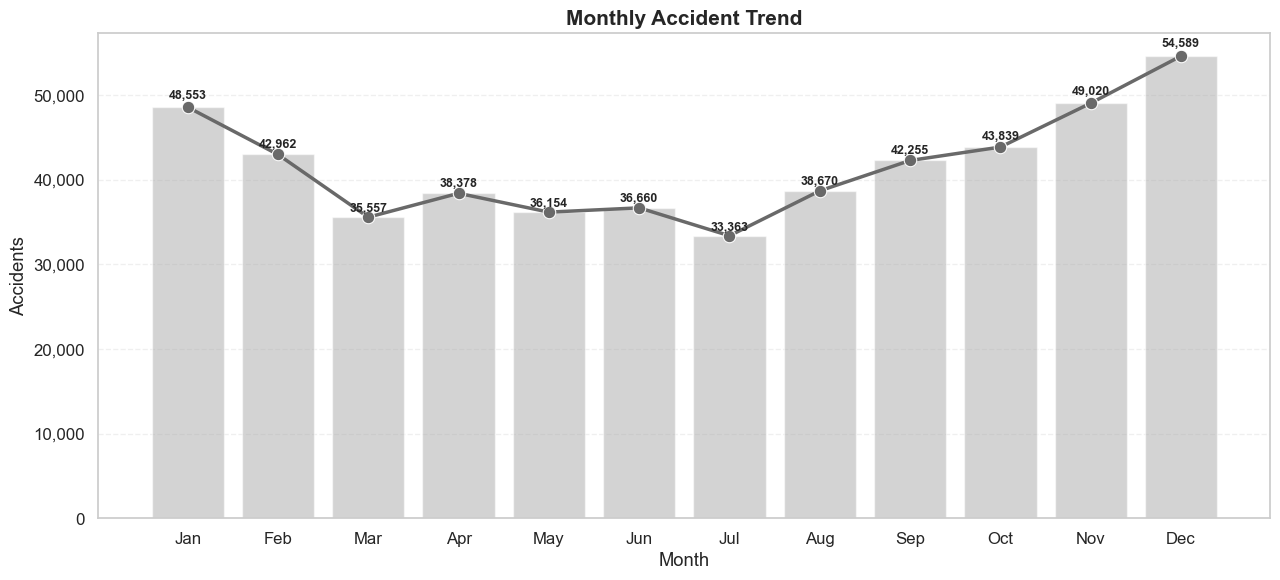

In [7]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df['Month'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(x=month_names, y=monthly.values, color=LIGHT_GRAY, alpha=0.5, ax=ax)
sns.lineplot(x=month_names, y=monthly.values, marker='o',
             color=MAIN_GRAY, linewidth=2.5, markersize=9, ax=ax)
for i, v in enumerate(monthly.values):
    ax.text(i, v*1.02, f'{v:,}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Monthly Accident Trend', fontsize=15, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Accidents')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout(); plt.show(); plt.close()

## 8. Temporal Analysis — Daily

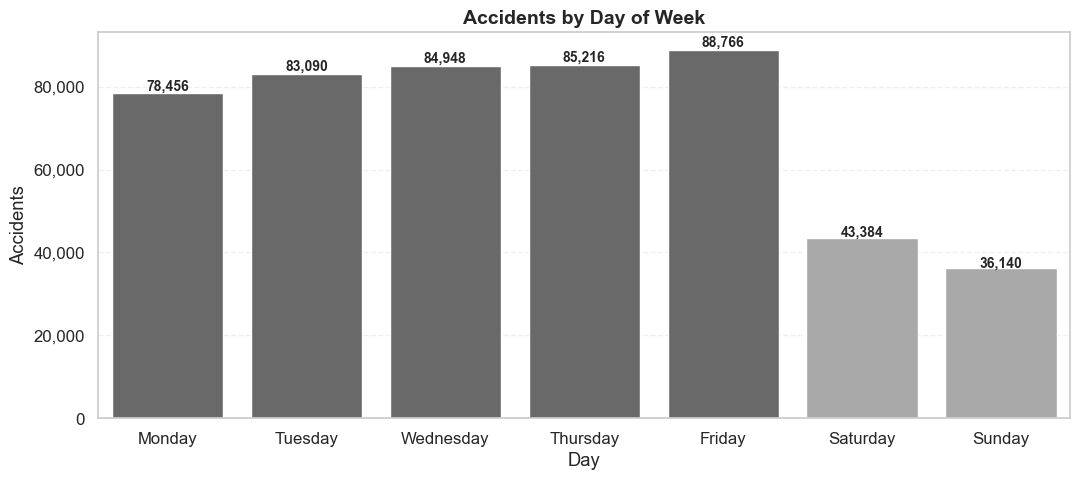

In [8]:
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily      = df['Day_of_Week'].value_counts().reindex(days_order)
colors_d   = [MAIN_GRAY if i < 5 else LIGHT_GRAY for i in range(7)]

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=daily.index, y=daily.values,
            palette=colors_d, hue=daily.index, legend=False, ax=ax)
for i, v in enumerate(daily.values):
    ax.text(i, v*1.01, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Accidents by Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day'); ax.set_ylabel('Accidents')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout(); plt.show(); plt.close()

## 9. Temporal Analysis — Hourly

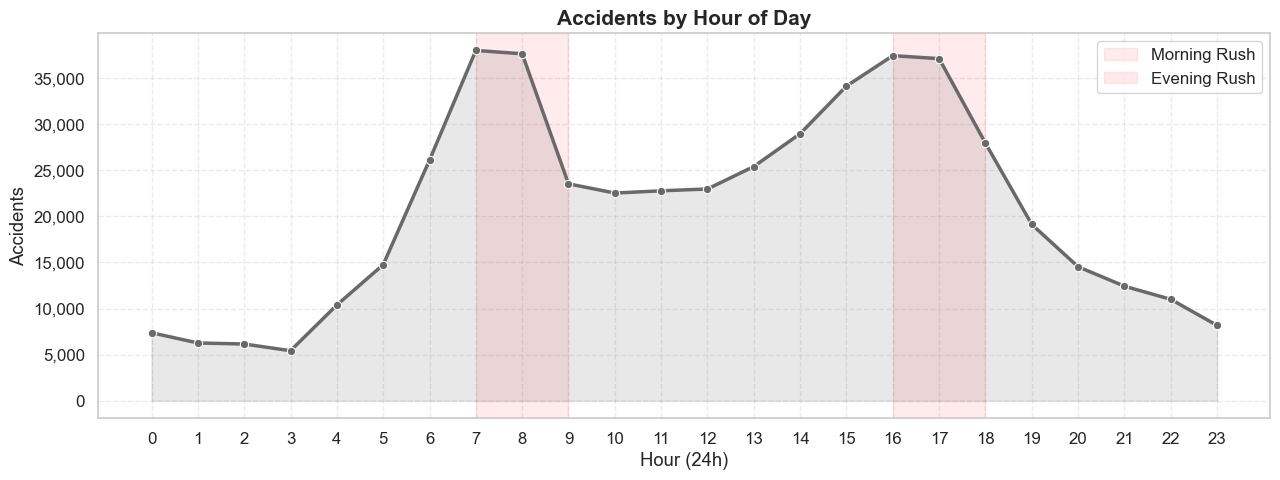

In [9]:
hourly = df['Hour'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(x=hourly.index, y=hourly.values,
             marker='o', color=MAIN_GRAY, linewidth=2.5, ax=ax)
ax.fill_between(hourly.index, hourly.values, color=MAIN_GRAY, alpha=0.15)
ax.axvspan(7,  9,  color='red', alpha=0.08, label='Morning Rush')
ax.axvspan(16, 18, color='red', alpha=0.08, label='Evening Rush')
ax.set_xticks(range(24))
ax.set_title('Accidents by Hour of Day', fontsize=15, fontweight='bold')
ax.set_xlabel('Hour (24h)'); ax.set_ylabel('Accidents')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(linestyle='--', alpha=0.4); ax.legend()
plt.tight_layout(); plt.show(); plt.close()

## 10. Environmental Analysis — Temperature / Humidity / Pressure / Precipitation

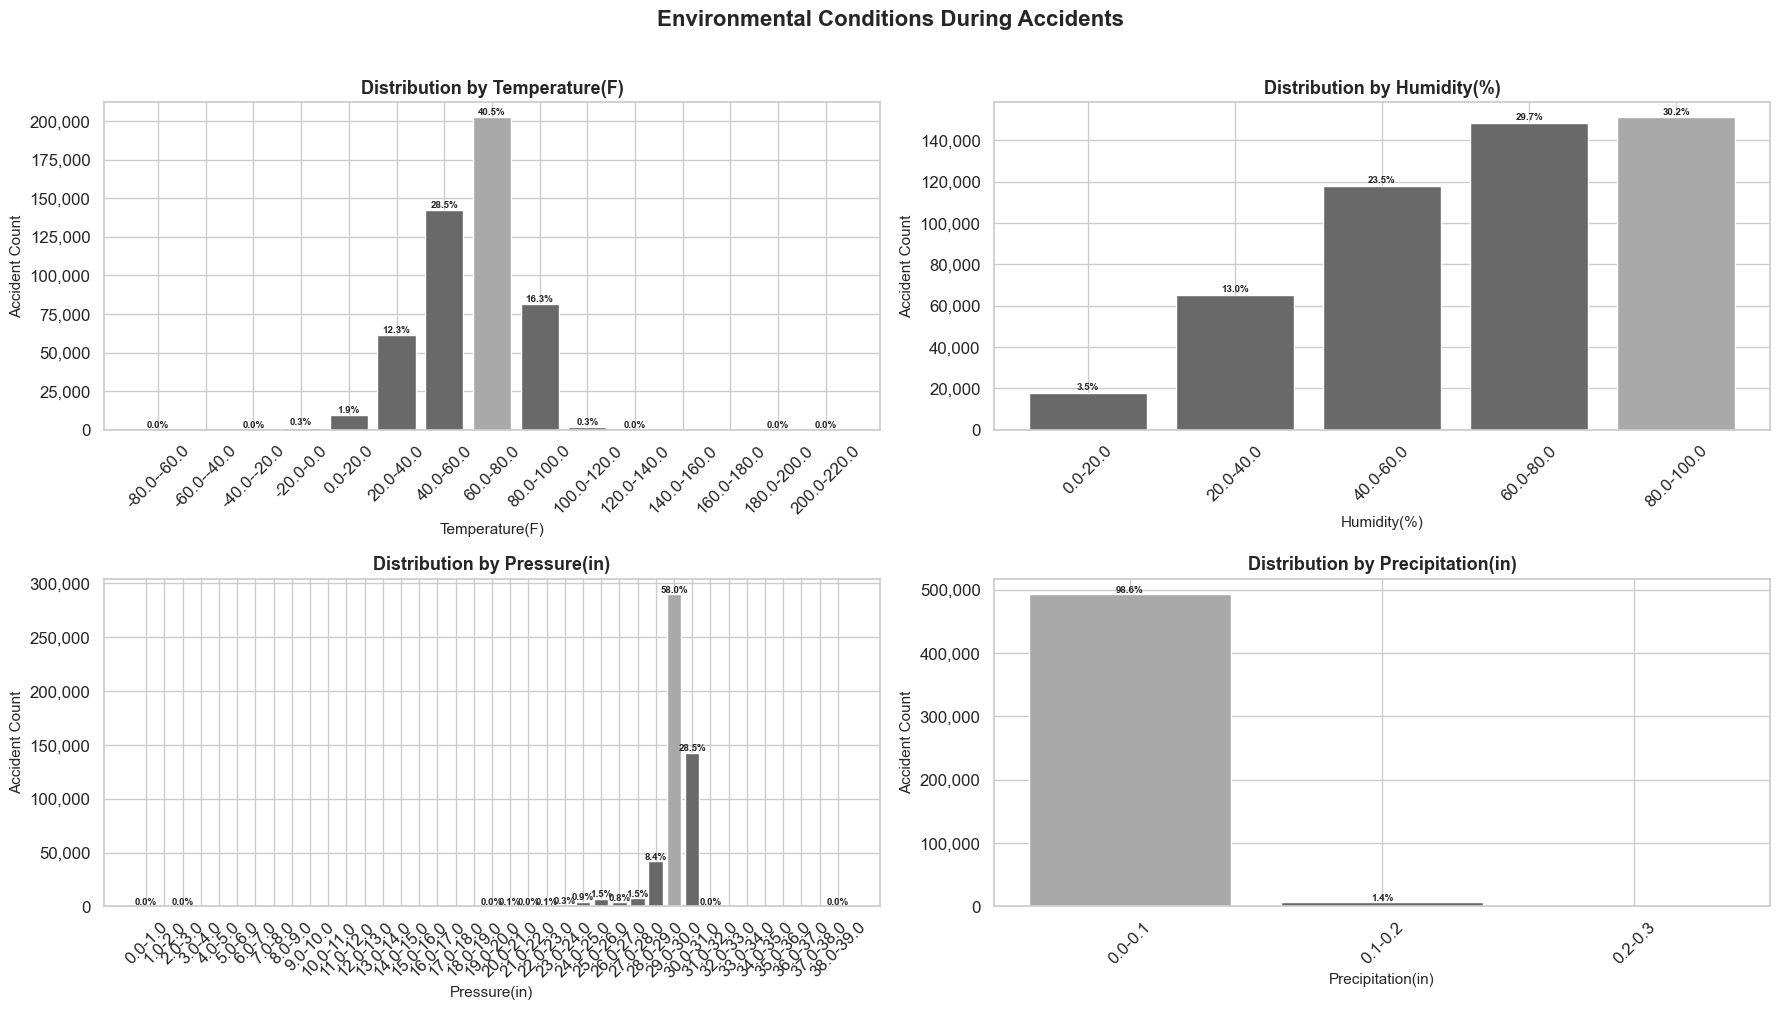

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
plot_env(df,      'Temperature(F)',    20,  axes[0, 0])
plot_env(df,      'Humidity(%)',       20,  axes[0, 1])
plot_env(df,      'Pressure(in)',       1,  axes[1, 0])
plot_env(df_plot, 'Precipitation(in)', 0.1, axes[1, 1])
plt.suptitle('Environmental Conditions During Accidents',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show(); plt.close()

## 11. Environmental Analysis — Wind Speed / Wind Chill / Wind Chill Effect

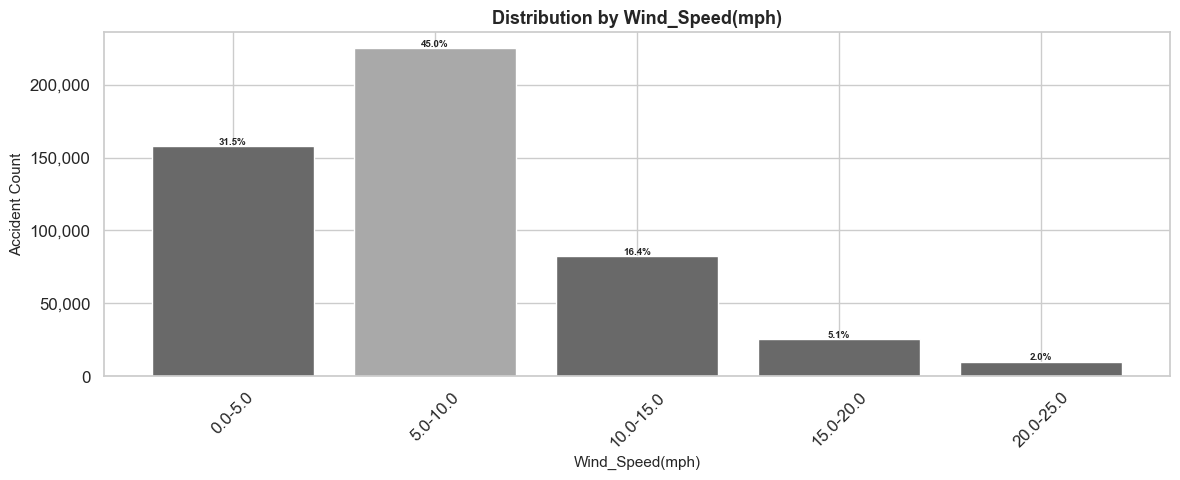

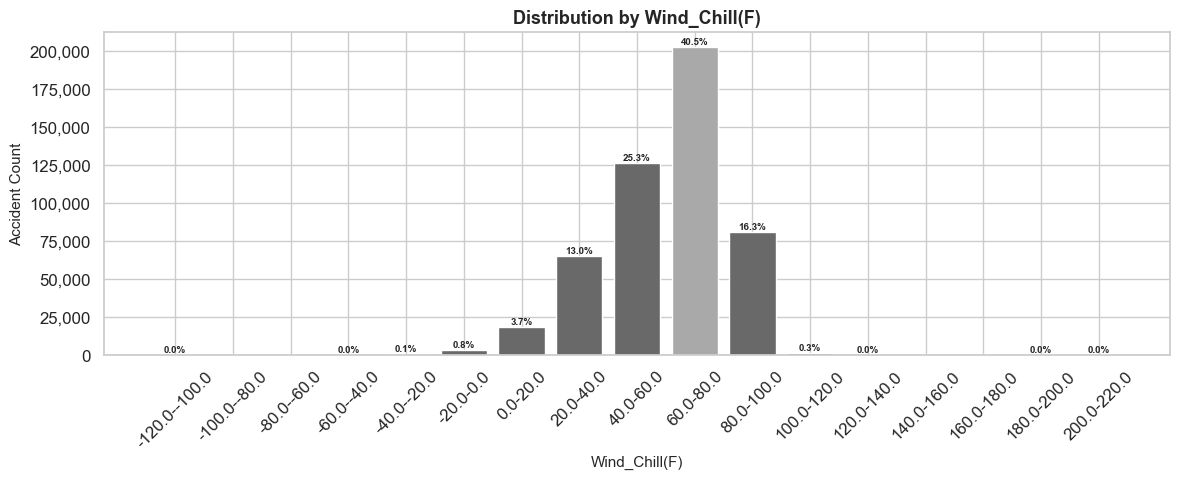

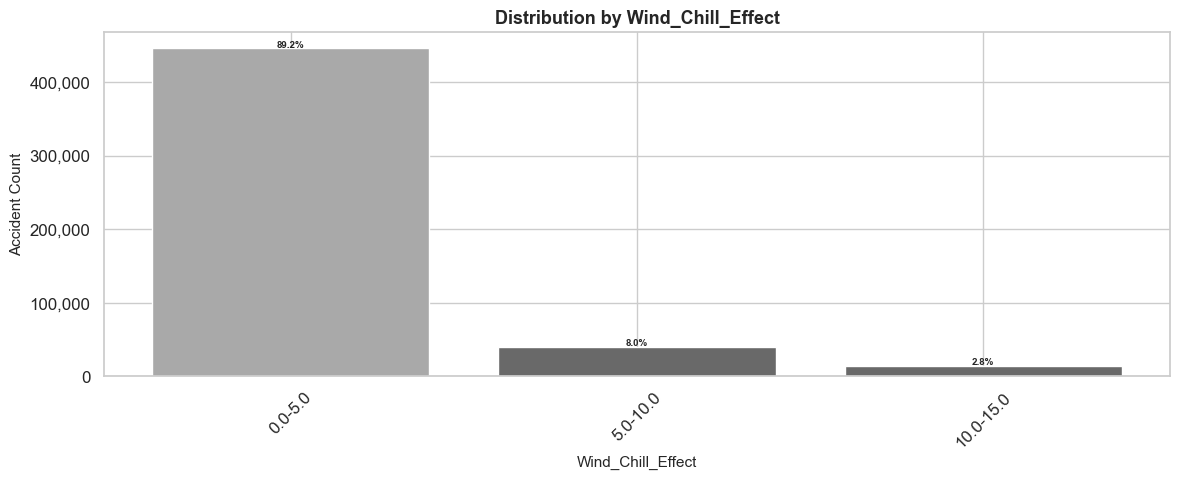

In [11]:
plot_env(df_plot, 'Wind_Speed(mph)',   5)
plot_env(df,      'Wind_Chill(F)',    20)
plot_env(df_plot, 'Wind_Chill_Effect', 5)

## 12. Visibility Pie Chart

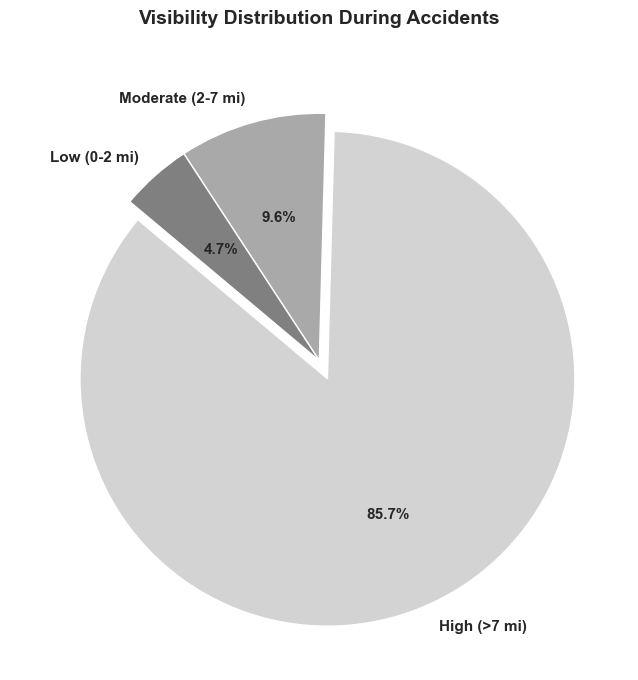

In [12]:
vis_counts = df['Visibility_Category'].value_counts()
max_idx    = vis_counts.values.argmax()
explode    = [0.08 if i == max_idx else 0 for i in range(len(vis_counts))]

fig, ax = plt.subplots(figsize=(8, 7))
ax.pie(vis_counts.values, explode=explode, labels=vis_counts.index,
       colors=GRAY4[:len(vis_counts)], autopct='%1.1f%%',
       startangle=140, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax.set_title('Visibility Distribution During Accidents',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout(); plt.show(); plt.close()

## 13. Top 15 Weather Conditions

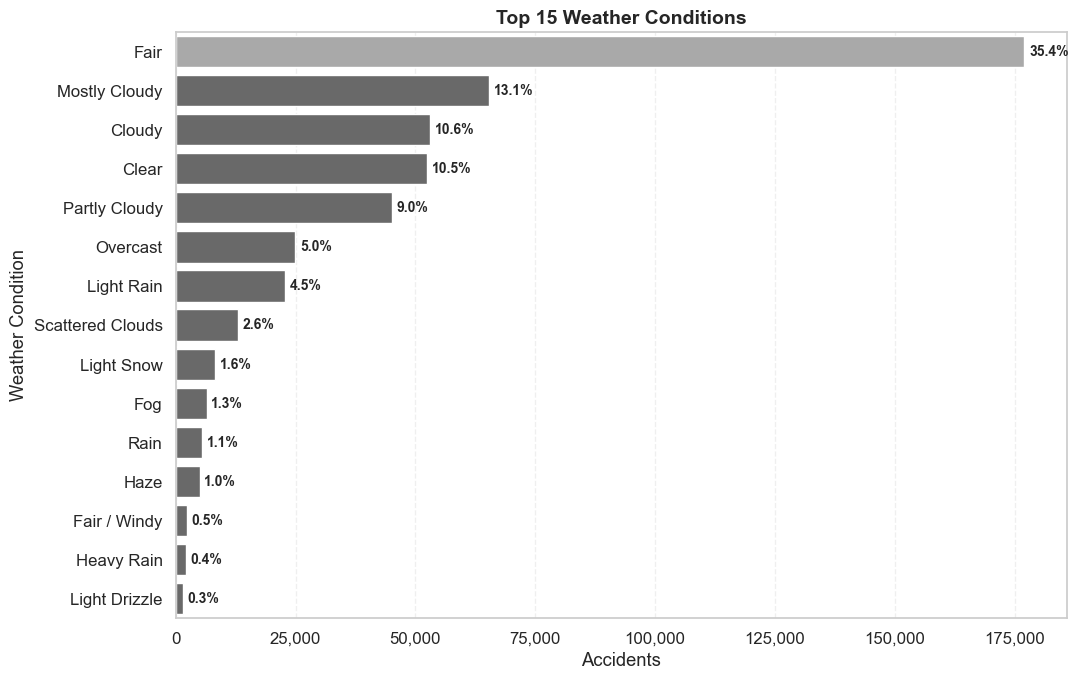

In [13]:
top_wx   = df['Weather_Condition'].value_counts().head(15)
total_wx = df['Weather_Condition'].notna().sum()

fig, ax = plt.subplots(figsize=(11, 7))
colors_wx = [LIGHT_GRAY if i == 0 else MAIN_GRAY for i in range(len(top_wx))]
sns.barplot(x=top_wx.values, y=top_wx.index,
            palette=colors_wx, hue=top_wx.index, legend=False, ax=ax)
for i, v in enumerate(top_wx.values):
    ax.text(v + total_wx*0.002, i, f'{v/total_wx*100:.1f}%',
            va='center', fontsize=10, fontweight='bold')
ax.set_title('Top 15 Weather Conditions', fontsize=14, fontweight='bold')
ax.set_xlabel('Accidents'); ax.set_ylabel('Weather Condition')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout(); plt.show(); plt.close()

## 14. Day vs Night Pie Chart

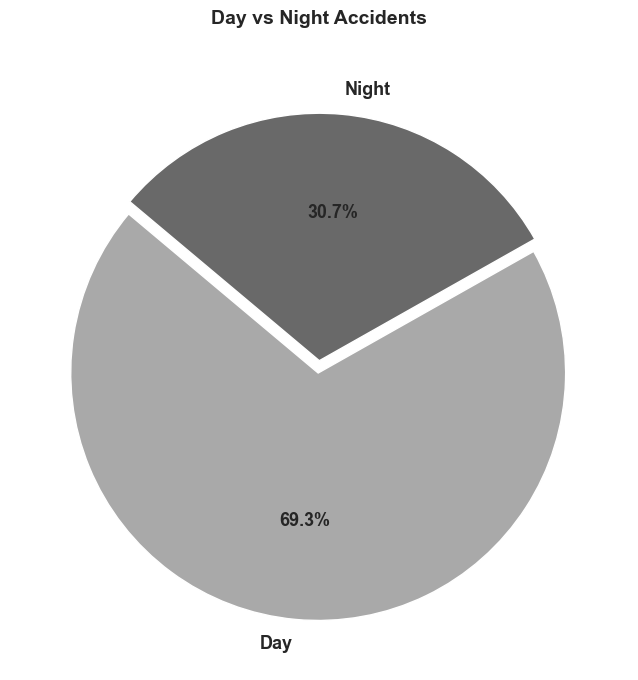

In [14]:
dn_counts = df['Sunrise_Sunset'].value_counts()
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(dn_counts.values, explode=[0.05, 0],
       labels=dn_counts.index, colors=[LIGHT_GRAY, MAIN_GRAY],
       autopct='%1.1f%%', startangle=140,
       textprops={'fontsize': 13, 'fontweight': 'bold'})
ax.set_title('Day vs Night Accidents', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout(); plt.show(); plt.close()

## 15. Roadway Features — 13 Pie Charts

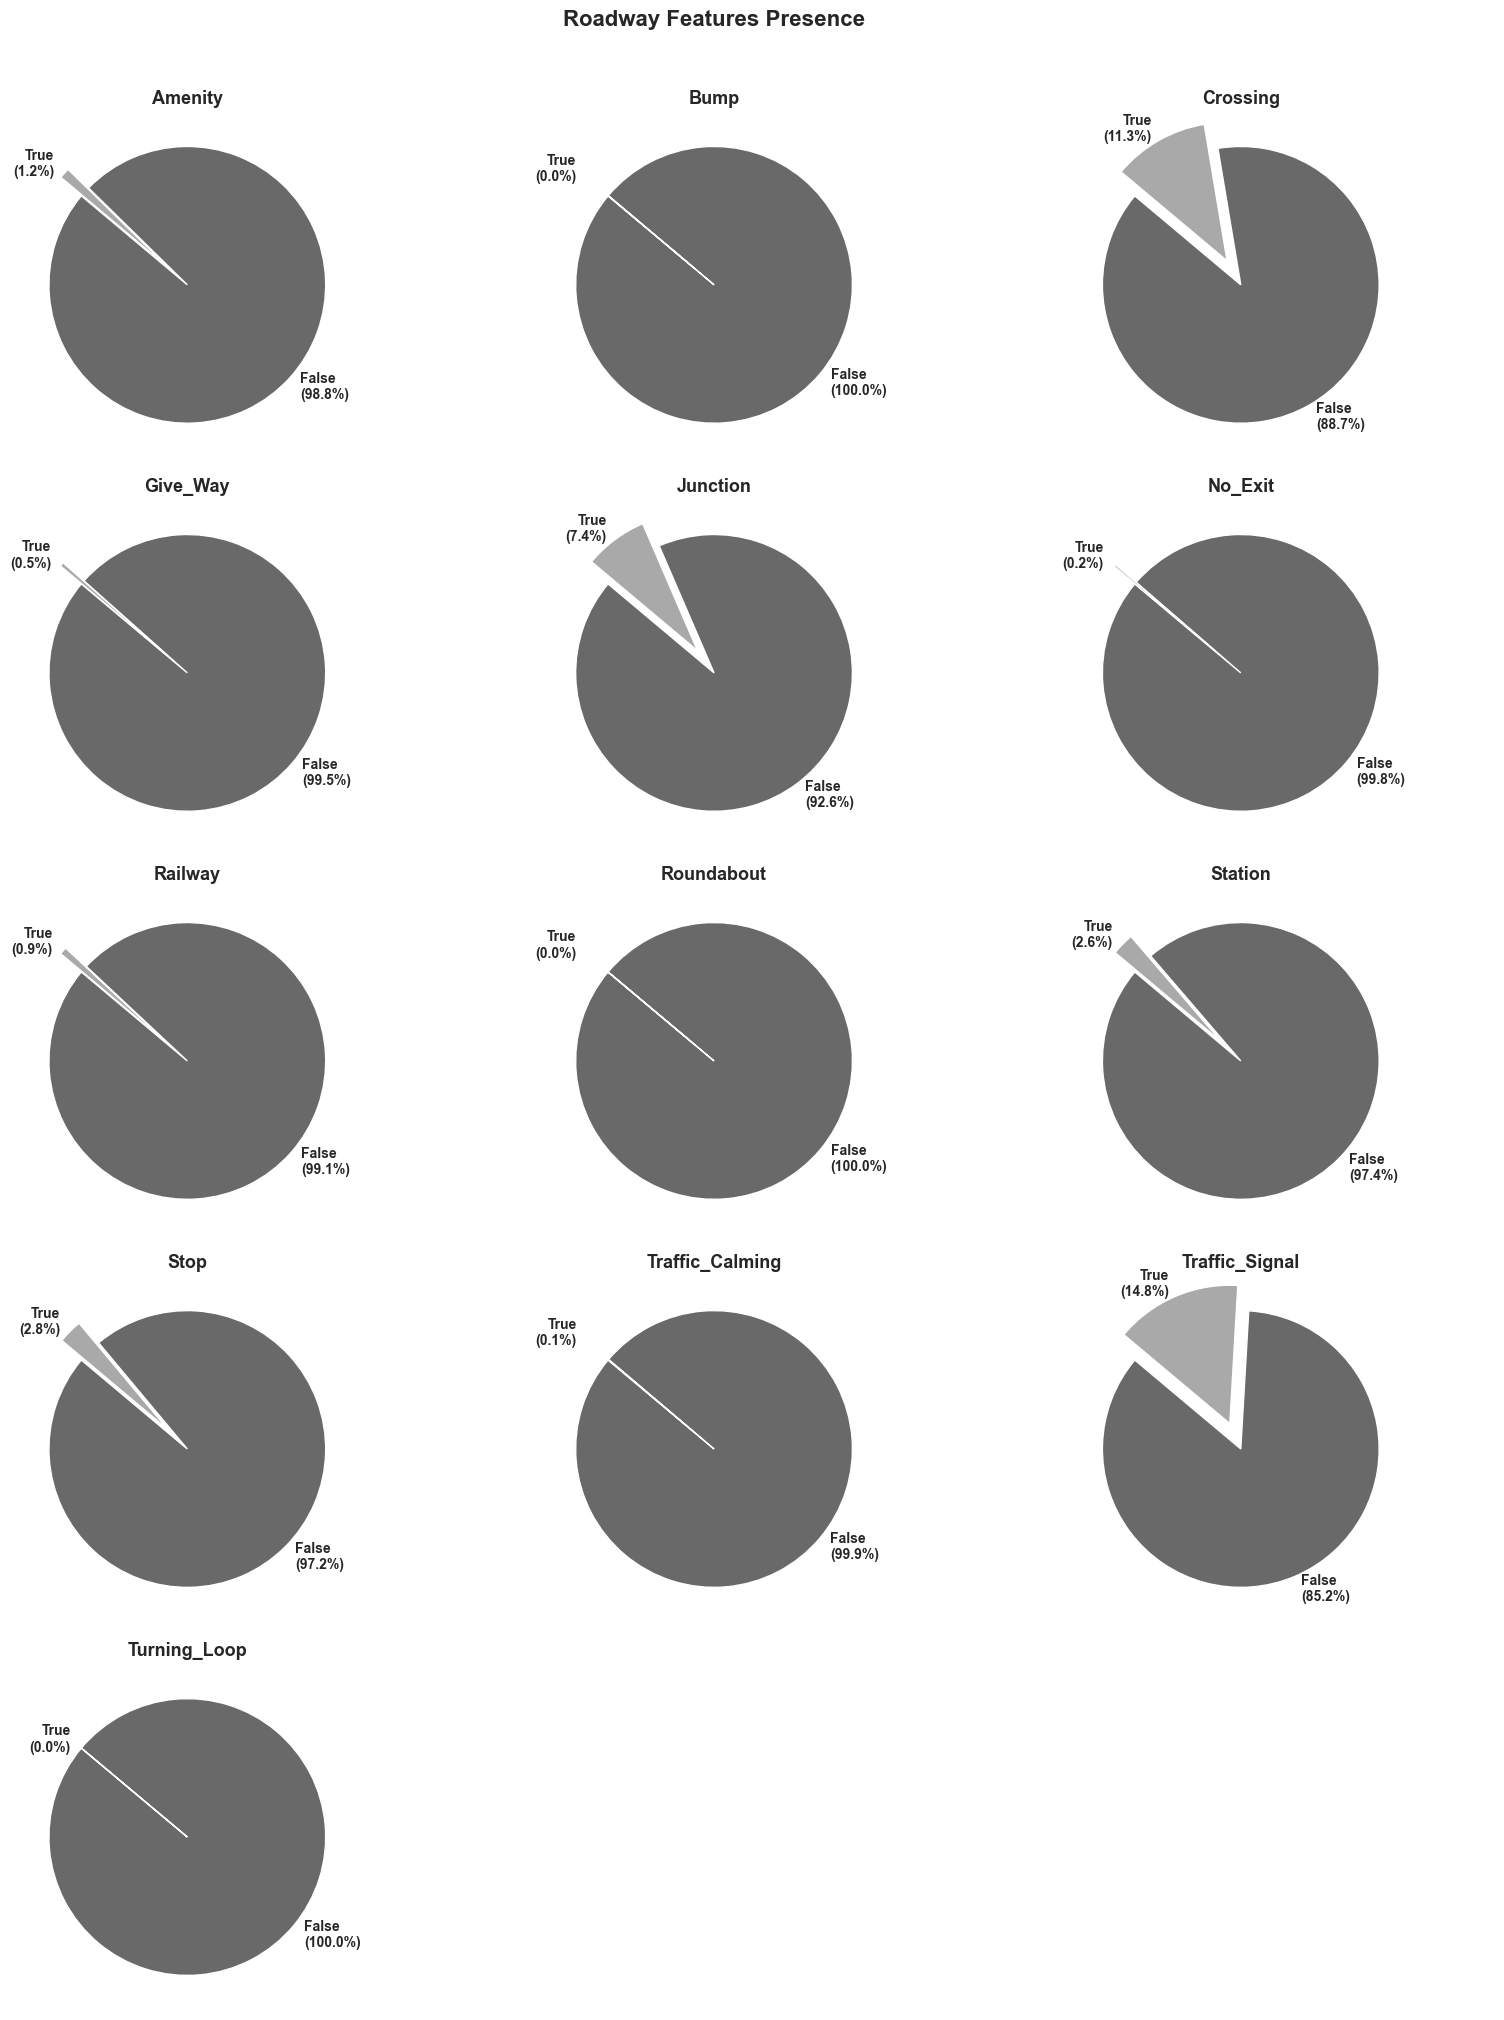

In [15]:
roadway_features = ['Amenity','Bump','Crossing','Give_Way','Junction',
                    'No_Exit','Railway','Roundabout','Station','Stop',
                    'Traffic_Calming','Traffic_Signal','Turning_Loop']

fig, axes = plt.subplots(5, 3, figsize=(16, 20))
axes = axes.flatten()

for i, feature in enumerate(roadway_features):
    col_vals = df[feature].map({True: 1, False: 0, 1: 1, 0: 0})
    counts   = col_vals.value_counts().reindex([0, 1], fill_value=0)
    total    = counts.sum()
    if total == 0:
        axes[i].axis('off'); continue
    pcts    = counts / total * 100
    values  = counts.values.astype(float)
    labels  = [f'False\n({pcts[0]:.1f}%)', f'True\n({pcts[1]:.1f}%)']
    explode = [0, 0.2] if counts[1] > 0 else [0, 0]
    axes[i].pie(values, labels=labels, colors=[MAIN_GRAY, LIGHT_GRAY],
                startangle=140, explode=explode,
                textprops={'fontsize': 10, 'fontweight': 'bold'})
    axes[i].set_title(feature, fontsize=13, fontweight='bold')

for j in range(len(roadway_features), len(axes)):
    axes[j].axis('off')

plt.suptitle('Roadway Features Presence', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('roadway_features_analysis.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

## 16. Outlier Detection — Boxplot

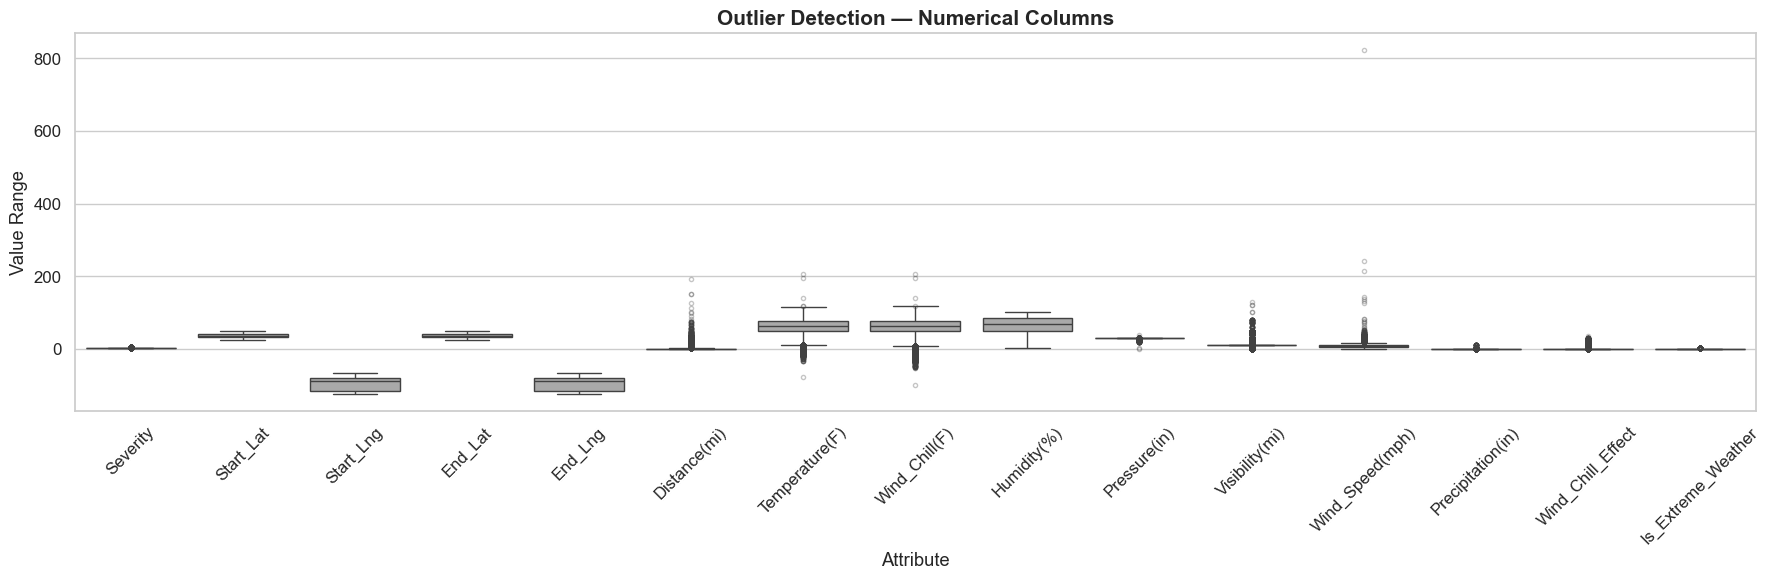

EDA Complete — All plots done!


In [16]:
num_df = df.select_dtypes(include=['int64', 'float64'])
fig, ax = plt.subplots(figsize=(18, 6))
sns.boxplot(data=num_df, color=LIGHT_GRAY, ax=ax,
            flierprops=dict(marker='.', alpha=0.3))
ax.set_title('Outlier Detection — Numerical Columns', fontsize=15, fontweight='bold')
ax.set_xlabel('Attribute'); ax.set_ylabel('Value Range')
plt.xticks(rotation=45)
plt.tight_layout(); plt.show(); plt.close()

print('EDA Complete — All plots done!')